# 01.2 — NumPy: pixels, views and broadcasting

**CPU · Synthetic input · No downloads**

## Learning Objectives

Read shapes and dtypes, choose pixels and regions, distinguish views from copies, apply channel gains with broadcasting and compare a from-scratch grayscale transform with OpenCV.

## Prerequisites

Notebook 01's Python structures and functions. Run all cells in this notebook from a fresh kernel; no variables from another notebook are used.

## 1. Introduction

A NumPy array is a numerical grid with a consistent dtype. Instead of building a new Python list for each row, we can express an operation on the whole grid. First inspect the input contract.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

from cvzero.images import adjust_channels, crop_rgb
from cvzero.synthetic import make_scene

image = make_scene(height=80, width=120, seed=42)
print("shape:", image.shape, "dtype:", image.dtype)
print("pixel [y=10, x=20]:", image[10, 20].tolist())
print("red value there:", int(image[10, 20, 0]))
assert image.shape == (80, 120, 3)

shape: (80, 120, 3) dtype: uint8
pixel [y=10, x=20]: [65, 54, 47]
red value there: 65


## 2. Intuition

An array is like a labeled stack of tables. Its **axes** describe the directions along which you can select or combine values. Here axis 0 is rows, axis 1 is columns and axis 2 is channels. Summing along the channel axis removes that axis, leaving one number per location.

A slice can be a window into the same table, not a second copy of the table. That distinction becomes visible when you edit it.

## 3. Mathematical Foundation

For each channel, apply a gain $g_c$: $J_{yxc}=\operatorname{clip}(I_{yxc}g_c,0,255)$. $I$ is the input, $J$ the output, and $g_c$ a multiplier for red, green or blue. With pixel `(100,80,40)` and gains `(1.2,1.0,0.5)`, the result is `(120,80,20)`.

Shapes `(H,W,3)` and `(3,)` align at the rightmost dimension. That is why one three-value vector can be reused over all pixels. Dimensions must match or have size one; broadcasting is a rule, not a guess about meaning.

Storage is $B=HWC s$ bytes, where $s$ is bytes per value. Our `uint8` array has $80\cdot120\cdot3\cdot1=28{,}800$ element bytes. This excludes object overhead and temporaries.

In [2]:
pixel = np.array([[[100, 80, 40]]], dtype=np.uint8)
gains = np.array([1.2, 1.0, 0.5])
calculated = np.rint(np.clip(pixel.astype(float) * gains, 0, 255)).astype(np.uint8)
assert calculated.tolist() == [[[120, 80, 20]]]
print("Element bytes:", image.nbytes)
print("Float64 element bytes:", image.astype(np.float64).nbytes)

Element bytes: 28800
Float64 element bytes: 230400


## 4. Visual Explanation

Select one channel at a time. For a color-plane display, retain a three-channel array and put zeros into the other channels. A single-channel display would instead show numbers using a chosen color map.

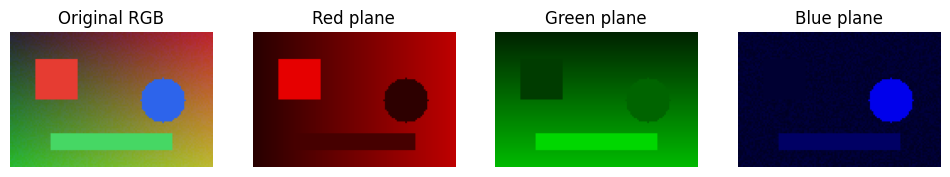

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image)
axes[0].set_title("Original RGB")
for channel, name in enumerate(["Red plane", "Green plane", "Blue plane"]):
    isolated = np.zeros_like(image)
    isolated[..., channel] = image[..., channel]
    axes[channel + 1].imshow(isolated)
    axes[channel + 1].set_title(name)
for ax in axes:
    ax.set_axis_off()
plt.show()

## 5. Basic Implementation

Choose a rectangle with exclusive end indices. `image[10:40,20:70]` contains 30 rows and 50 columns. Use `.copy()` to make an independent crop. The package wrapper also checks invalid bounds; ordinary slicing can silently shorten a requested range.

In [4]:
crop = image[10:40, 20:70].copy()
checked_crop = crop_rgb(image, 20, 10, 70, 40)
np.testing.assert_array_equal(crop, checked_crop)
assert crop.shape == (30, 50, 3)

working = image.copy()
view = working[10:20, 20:30]
view[:] = [255, 255, 255]
assert np.all(working[10:20, 20:30] == 255)
independent = working[10:20, 20:30].copy()
independent[:] = 0
assert np.all(working[10:20, 20:30] == 255)
print("View shares memory:", np.shares_memory(view, working))
print("Copy shares memory:", np.shares_memory(independent, working))

View shares memory: True
Copy shares memory: False


## 6. OpenCV Implementation

`cv2.split` creates channel arrays and `cv2.merge` combines them. It does not know whether we intended RGB or BGR; that meaning comes from our input contract. For a grayscale transform, specify `COLOR_RGB2GRAY` because the current image is RGB.

In [5]:
red, green, blue = cv2.split(image)
merged = cv2.merge((red, green, blue))
np.testing.assert_array_equal(merged, image)
cv_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
print("Each plane:", red.shape, "Gray:", cv_gray.shape)

Each plane: (80, 120) Gray: (80, 120)


## 7. From-Scratch Implementation

Use a weighted sum: $Y=0.299R+0.587G+0.114B$. $Y$ is the new grayscale value and $R,G,B$ are encoded color values. For pure red, $0.299\times255=76.245$, rounded to 76. This is a practical grayscale approximation, not physical luminance. We sum axis 2 because that is the channel axis.

In [6]:
def gray_from_arrays(rgb):
    """A visible weighted sum without cv2.cvtColor."""
    weights = np.array([0.299, 0.587, 0.114])
    values = (rgb.astype(np.float64) * weights).sum(axis=2)
    return np.rint(np.clip(values, 0, 255)).astype(np.uint8)


numpy_gray = gray_from_arrays(image)
max_error = int(np.abs(numpy_gray.astype(np.int16) - cv_gray.astype(np.int16)).max())
print("Maximum difference from OpenCV:", max_error, "intensity levels")
assert max_error <= 1
assert gray_from_arrays(np.array([[[255, 0, 0]]], dtype=np.uint8)).item() == 76

Maximum difference from OpenCV: 1 intensity levels


## 8. Experiment

First expose integer overflow with arrays of the same dtype. Then fix it by converting before arithmetic. Changing the type after a wrapped operation cannot recover the original value.

In [7]:
bright_pixel = np.array([250, 10, 0], dtype=np.uint8)
offset = np.full(3, 20, dtype=np.uint8)
wrapped = bright_pixel + offset
safe = np.clip(bright_pixel.astype(np.int16) + 20, 0, 255).astype(np.uint8)
print("Wrapped uint8 addition:", wrapped.tolist())
print("Clipped addition:", safe.tolist())
assert wrapped[0] == 14 and safe[0] == 255

selected_gains = (1.2, 1.0, 0.5)  # Change one value at a time.
edited = adjust_channels(image, selected_gains)
red_mask = image[..., 0] > 180
print("Pixels with red > 180:", int(red_mask.sum()))

Wrapped uint8 addition: [14, 30, 20]
Clipped addition: [255, 30, 20]
Pixels with red > 180: 1240


The boolean mask has one `True` or `False` per pixel. Summing it counts selected locations. A red-channel threshold alone does not detect “red objects”: white and yellow can also have a high red value. Color-space reasoning arrives in later chapters.

## 9. Visualization

Compare a crop, the gain edit and the weighted grayscale. Use a fixed grayscale range to make values comparable, not automatically stretched per image.

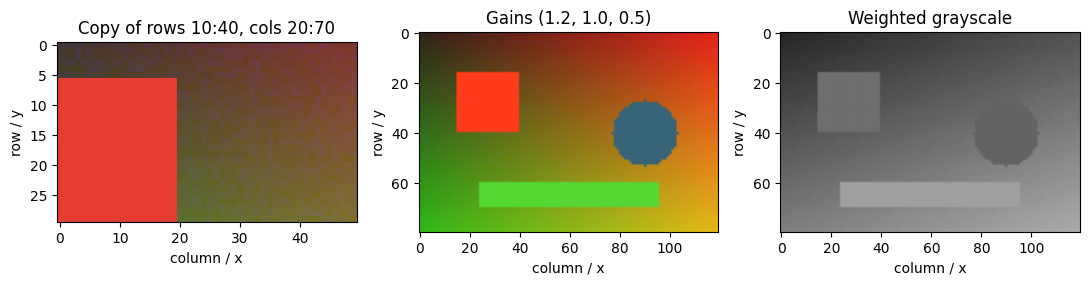

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
axes[0].imshow(crop)
axes[0].set_title("Copy of rows 10:40, cols 20:70")
axes[1].imshow(edited)
axes[1].set_title(f"Gains {selected_gains}")
axes[2].imshow(numpy_gray, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Weighted grayscale")
for ax in axes:
    ax.set_xlabel("column / x")
    ax.set_ylabel("row / y")
plt.tight_layout()
plt.show()

## 10. Real-World Application

Array contracts and region selection appear in document cropping, channel preprocessing and model input preparation. A fast whole-array expression can reduce Python overhead, but dtype conversion and intermediate arrays still cost memory.

## 11. Common Mistakes

- Adding within `uint8` before converting.
- Cropping `[x0:x1,y0:y1]` instead of `[y0:y1,x0:x1]`.
- Assuming a slice is always independent.
- Applying `(3,1)` gains when `(3,)` is intended for an HWC image.
- Treating a high red value as a reliable red-object detector.

## 12. Exercises

**Easy:** print the three means using `image.mean(axis=(0,1))` and explain the remaining axis.

**Medium:** set only pixels selected by a boolean mask to a new RGB color in a copy.

**Hard:** create two spatially different images with exactly equal per-channel histograms. Explain why the histograms cannot tell them apart.

## 13. Challenge

Create a “channel inspector” function that returns a dictionary containing shape, dtype, bytes, per-channel ranges and a copied region. Decide how to validate the region and show evidence that the input cannot be changed through the returned crop. No solution is supplied.

## 14. Summary

Shape says where values are; dtype says how they are stored. Slices may share storage, while copies are independent. Broadcasting applies compatible smaller arrays without writing pixel loops. Correct arithmetic requires an explicit range and casting policy.

## 15. Next Step

Open [03 — Functions, classes and files](03_functions_classes_files.ipynb). Turn these operations into a reusable file workflow. References: [NumPy indexing](https://numpy.org/doc/stable/user/basics.indexing.html), [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html), [OpenCV](https://docs.opencv.org/4.x/d3/df2/tutorial_py_basic_ops.html).